In [11]:
import numpy as np
import pandas as pd
import seaborn as sns

In [12]:
df = sns.load_dataset('iris')

In [13]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
encoder = LabelEncoder()

In [16]:
df['species'] = encoder.fit_transform(df['species'])

In [17]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [18]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [19]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

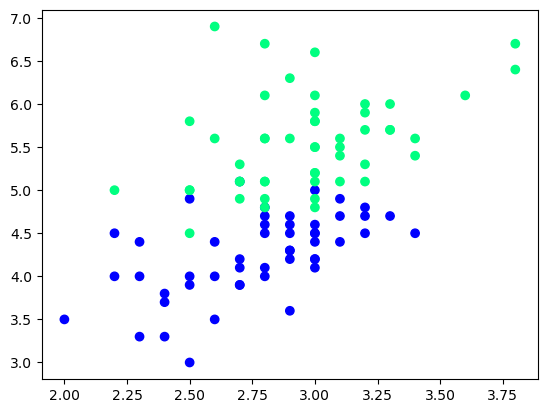

In [21]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [22]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
104,3.0,5.8,2
77,3.0,5.0,1
61,3.0,4.2,1
107,2.9,6.3,2
93,2.3,3.3,1
80,2.4,3.8,1
72,2.5,4.9,1
53,2.3,4.0,1
98,2.5,3.0,1
85,3.4,4.5,1


In [23]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [24]:
df_train

,sepal_width,petal_length,species
120,3.2,5.7,2
63,2.9,4.7,1
124,3.3,5.7,2
83,2.7,5.1,1
54,2.8,4.6,1
106,2.5,4.5,2
51,3.2,4.5,1
98,2.5,3.0,1
131,3.8,6.4,2
143,3.2,5.9,2


In [25]:
df_val

,sepal_width,petal_length,species
82,2.7,3.9,1
103,2.9,5.6,2
137,3.1,5.5,2
133,2.8,5.1,2
91,3.0,4.6,1


In [26]:
df_test

,sepal_width,petal_length,species
60,2.0,3.5,1
57,2.4,3.3,1
53,2.3,4.0,1
147,3.0,5.2,2
102,3.0,5.9,2


In [27]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [28]:
y_test

array([1, 2, 2, 2, 1])

# Case 1 - Bagging

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
63,2.9,4.7,1
51,3.2,4.5,1
124,3.3,5.7,2
98,2.5,3.0,1
120,3.2,5.7,2
63,2.9,4.7,1
106,2.5,4.5,2
143,3.2,5.9,2


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [31]:
dt_bag1 = DecisionTreeClassifier()

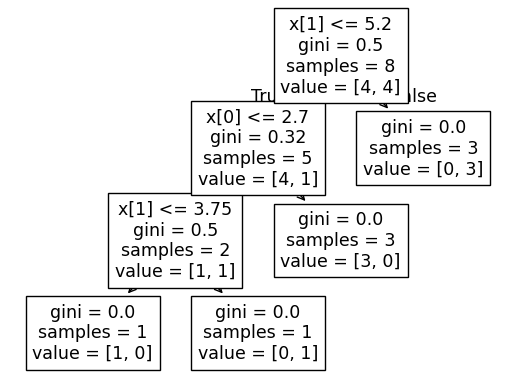

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


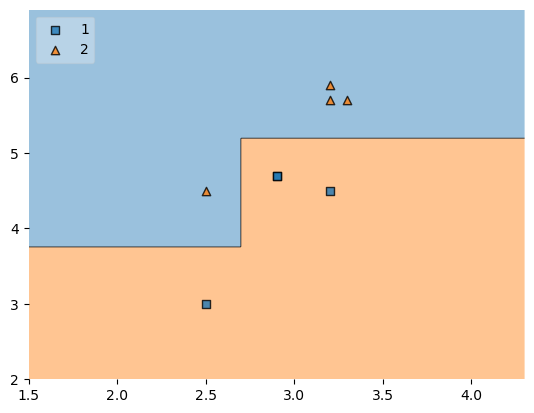

In [34]:
evaluate(dt_bag1,X,y)

In [35]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
54,2.8,4.6,1
124,3.3,5.7,2
106,2.5,4.5,2
83,2.7,5.1,1
51,3.2,4.5,1
131,3.8,6.4,2
131,3.8,6.4,2
143,3.2,5.9,2


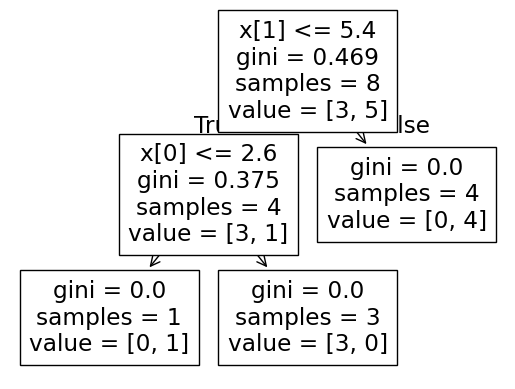

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


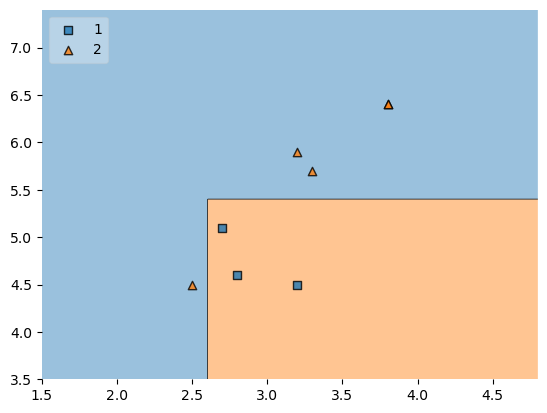

In [36]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [37]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
51,3.2,4.5,1
51,3.2,4.5,1
63,2.9,4.7,1
120,3.2,5.7,2
131,3.8,6.4,2
83,2.7,5.1,1
124,3.3,5.7,2
54,2.8,4.6,1


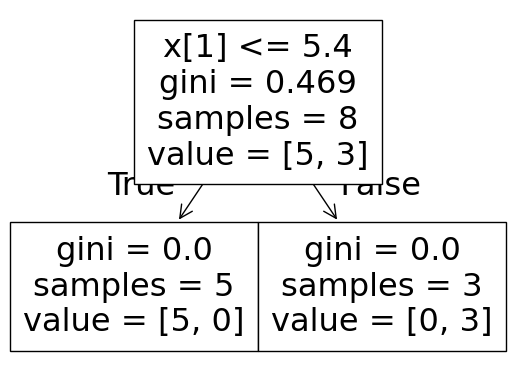

C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


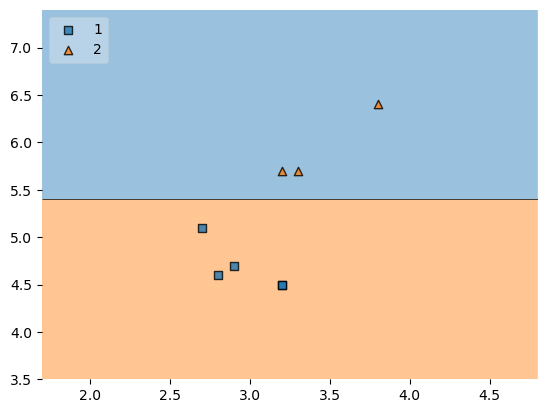

In [38]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [39]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [40]:
df_test

,sepal_width,petal_length,species
60,2.0,3.5,1
57,2.4,3.3,1
53,2.3,4.0,1
147,3.0,5.2,2
102,3.0,5.9,2


In [43]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [1]


C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Rafy Mustafa\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [44]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
120,3.2,5.7,2
63,2.9,4.7,1
124,3.3,5.7,2
83,2.7,5.1,1
54,2.8,4.6,1
106,2.5,4.5,2
51,3.2,4.5,1
98,2.5,3.0,1
131,3.8,6.4,2
143,3.2,5.9,2


In [45]:
df_train.sample(8)

,sepal_width,petal_length,species
98,2.5,3.0,1
51,3.2,4.5,1
131,3.8,6.4,2
120,3.2,5.7,2
83,2.7,5.1,1
106,2.5,4.5,2
124,3.3,5.7,2
63,2.9,4.7,1


# Random Subspaces

In [46]:
df1 = sns.load_dataset('iris')
df1 = df1.sample(10)

In [47]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
64,5.6,2.9,3.6,1.3,versicolor
61,5.9,3.0,4.2,1.5,versicolor
7,5.0,3.4,1.5,0.2,setosa
131,7.9,3.8,6.4,2.0,virginica
46,5.1,3.8,1.6,0.2,setosa
84,5.4,3.0,4.5,1.5,versicolor
65,6.7,3.1,4.4,1.4,versicolor
118,7.7,2.6,6.9,2.3,virginica
39,5.1,3.4,1.5,0.2,setosa
147,6.5,3.0,5.2,2.0,virginica


In [56]:
df1.sample(2,replace=True,axis=1)

,sepal_length,sepal_length
64,5.6,5.6
61,5.9,5.9
7,5.0,5.0
131,7.9,7.9
46,5.1,5.1
84,5.4,5.4
65,6.7,6.7
118,7.7,7.7
39,5.1,5.1
147,6.5,6.5


# Random Patches

In [57]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
64,5.6,2.9,3.6,1.3,versicolor
61,5.9,3.0,4.2,1.5,versicolor
7,5.0,3.4,1.5,0.2,setosa
131,7.9,3.8,6.4,2.0,virginica
46,5.1,3.8,1.6,0.2,setosa
84,5.4,3.0,4.5,1.5,versicolor
65,6.7,3.1,4.4,1.4,versicolor
118,7.7,2.6,6.9,2.3,virginica
39,5.1,3.4,1.5,0.2,setosa
147,6.5,3.0,5.2,2.0,virginica


In [60]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_width,sepal_length
64,2.9,5.6
118,2.6,7.7
61,3.0,5.9
131,3.8,7.9
39,3.4,5.1
65,3.1,6.7
147,3.0,6.5
147,3.0,6.5
